Random Forest MSE - Train: 460.4930932011332 Test: 2952.0105887640448
Decision Tree MSE - Train: 0.0 Test: 4976.797752808989


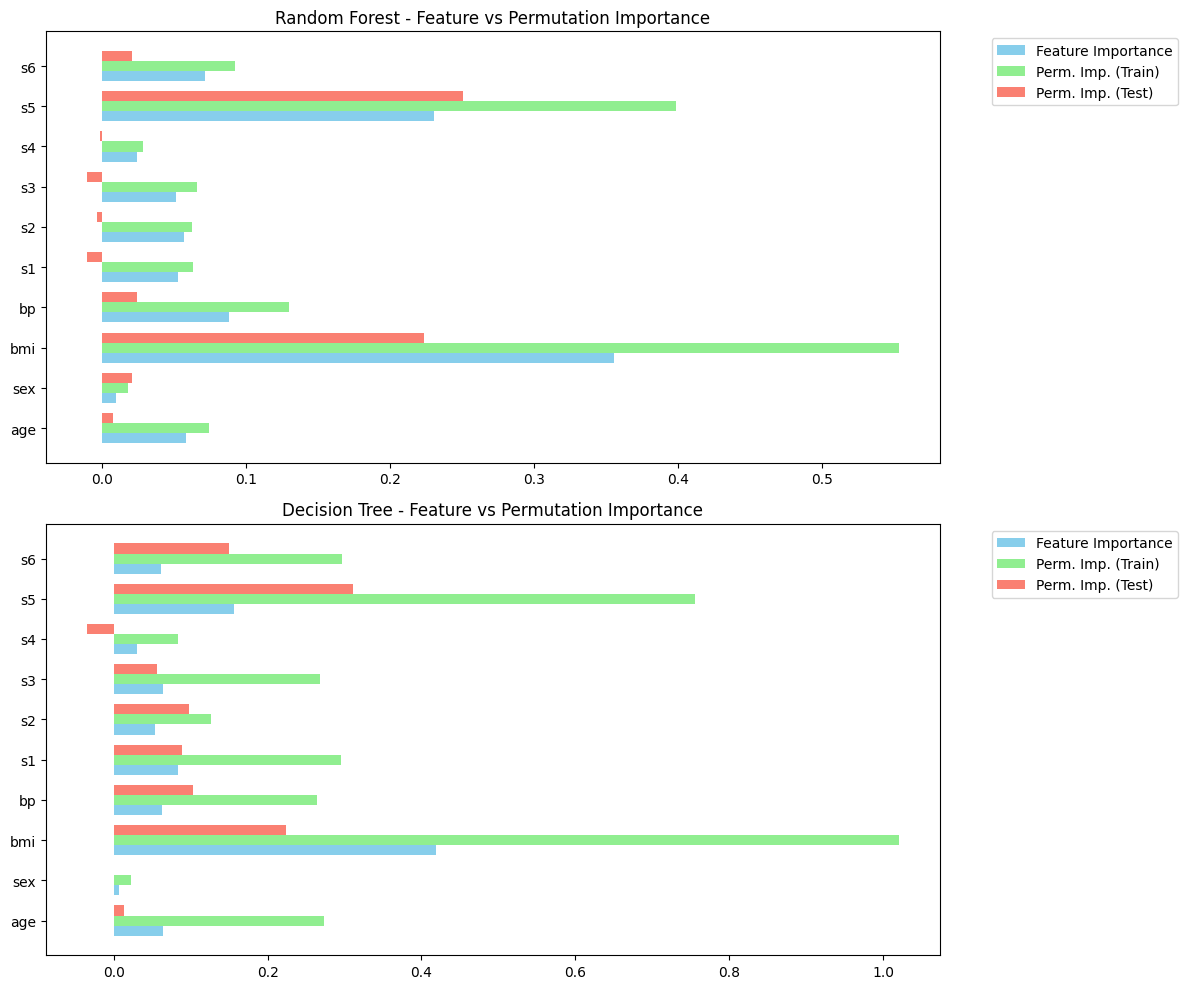

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error

# Carica il dataset
diabetes = load_diabetes()
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = diabetes.target

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Addestra i modelli
rf = RandomForestRegressor(random_state=42)
dt = DecisionTreeRegressor(random_state=42)

rf.fit(X_train, y_train)
dt.fit(X_train, y_train)

# Calcola MSE
rf_train_mse = mean_squared_error(y_train, rf.predict(X_train))
rf_test_mse = mean_squared_error(y_test, rf.predict(X_test))
dt_train_mse = mean_squared_error(y_train, dt.predict(X_train))
dt_test_mse = mean_squared_error(y_test, dt.predict(X_test))

print("Random Forest MSE - Train:", rf_train_mse, "Test:", rf_test_mse)
print("Decision Tree MSE - Train:", dt_train_mse, "Test:", dt_test_mse)

# Calcola permutation importance per entrambi i modelli
def get_permutation_importance(model, X, y):
    result = permutation_importance(model, X, y, n_repeats=10, random_state=42)
    return result.importances_mean

rf_perm_imp_train = get_permutation_importance(rf, X_train, y_train)
rf_perm_imp_test = get_permutation_importance(rf, X_test, y_test)
dt_perm_imp_train = get_permutation_importance(dt, X_train, y_train)
dt_perm_imp_test = get_permutation_importance(dt, X_test, y_test)

# Funzione per plottare feature importance e permutation importance orizzontalmente
def plot_importances(ax, feat_imp, perm_imp_train, perm_imp_test, title):
    y_pos = np.arange(len(diabetes.feature_names))
    width = 0.25

    ax.barh(y_pos - width, feat_imp, width, label='Feature Importance', color='skyblue')
    ax.barh(y_pos, perm_imp_train, width, label='Perm. Imp. (Train)', color='lightgreen')
    ax.barh(y_pos + width, perm_imp_test, width, label='Perm. Imp. (Test)', color='salmon')

    ax.set_yticks(y_pos)
    ax.set_yticklabels(diabetes.feature_names)
    ax.set_title(title)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Plot delle importances per entrambi i modelli
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

plot_importances(ax1, rf.feature_importances_, rf_perm_imp_train, rf_perm_imp_test,
                'Random Forest - Feature vs Permutation Importance')
plot_importances(ax2, dt.feature_importances_, dt_perm_imp_train, dt_perm_imp_test,
                'Decision Tree - Feature vs Permutation Importance')

plt.tight_layout()
plt.show()



# Attenti alla collinearità


Feature più importante: s5
Feature meno importante: s3


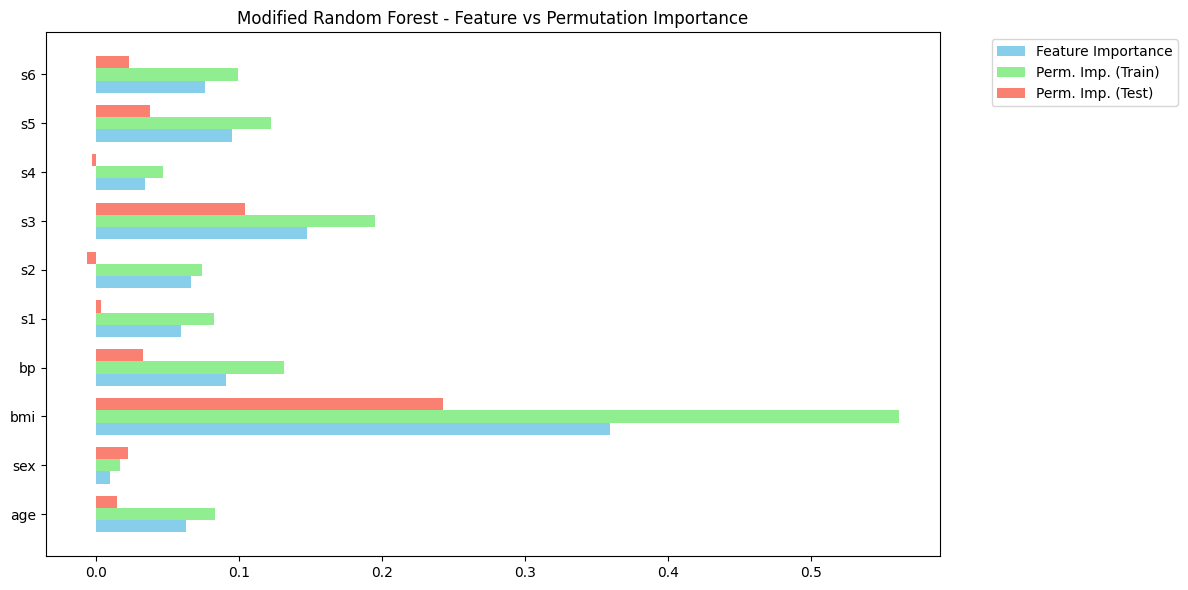

In [ ]:
# Trova la feature più e meno importante secondo la permutation importance del RF
most_imp_feature = diabetes.feature_names[np.argmax(rf_perm_imp_test)]
least_imp_feature = diabetes.feature_names[np.argmin(rf_perm_imp_test)]

print(f"\nFeature più importante: {most_imp_feature}")
print(f"Feature meno importante: {least_imp_feature}")

# Crea nuovo dataset sostituendo la feature meno importante
X_mod = X.copy()
X_mod[least_imp_feature] = X_mod[most_imp_feature]

# Split train/test per il nuovo dataset
X_mod_train, X_mod_test, y_mod_train, y_mod_test = train_test_split(X_mod, y, test_size=0.2, random_state=42)

# Addestra nuovo Random Forest
rf_mod = RandomForestRegressor(random_state=42)
rf_mod.fit(X_mod_train, y_mod_train)

# Calcola nuove importance
rf_mod_perm_imp_train = get_permutation_importance(rf_mod, X_mod_train, y_mod_train)
rf_mod_perm_imp_test = get_permutation_importance(rf_mod, X_mod_test, y_mod_test)

# Plot delle nuove importances
plt.figure(figsize=(12, 6))
plot_importances(plt.gca(), rf_mod.feature_importances_,
                rf_mod_perm_imp_train, rf_mod_perm_imp_test,
                'Modified Random Forest - Feature vs Permutation Importance')
plt.tight_layout()
plt.show()

# Combattiamo la multicollinearità

<ipython-input-15-4f18d20be5d2>:19: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = linkage(dist, method='complete')


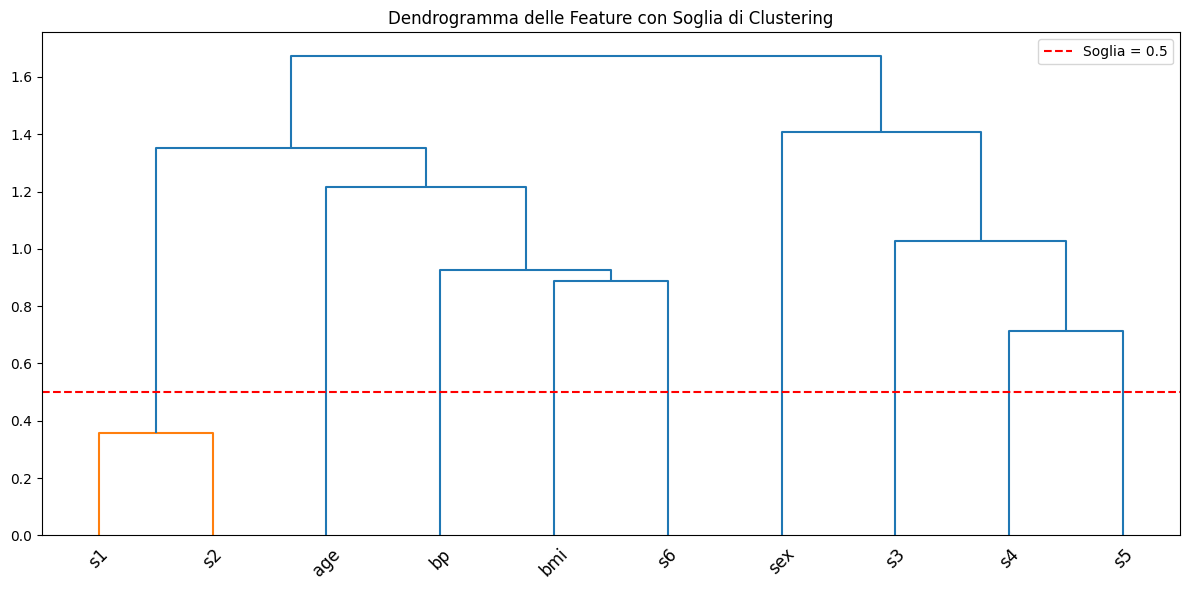


Composizione dei cluster:

Cluster 1:
  Rappresentante: s1
  Membri: s1, s2

Cluster 2:
  Rappresentante: bmi
  Membri: bmi

Cluster 3:
  Rappresentante: s6
  Membri: s6

Cluster 4:
  Rappresentante: bp
  Membri: bp

Cluster 5:
  Rappresentante: age
  Membri: age

Cluster 6:
  Rappresentante: s4
  Membri: s4

Cluster 7:
  Rappresentante: s5
  Membri: s5

Cluster 8:
  Rappresentante: s3
  Membri: s3

Cluster 9:
  Rappresentante: sex
  Membri: sex


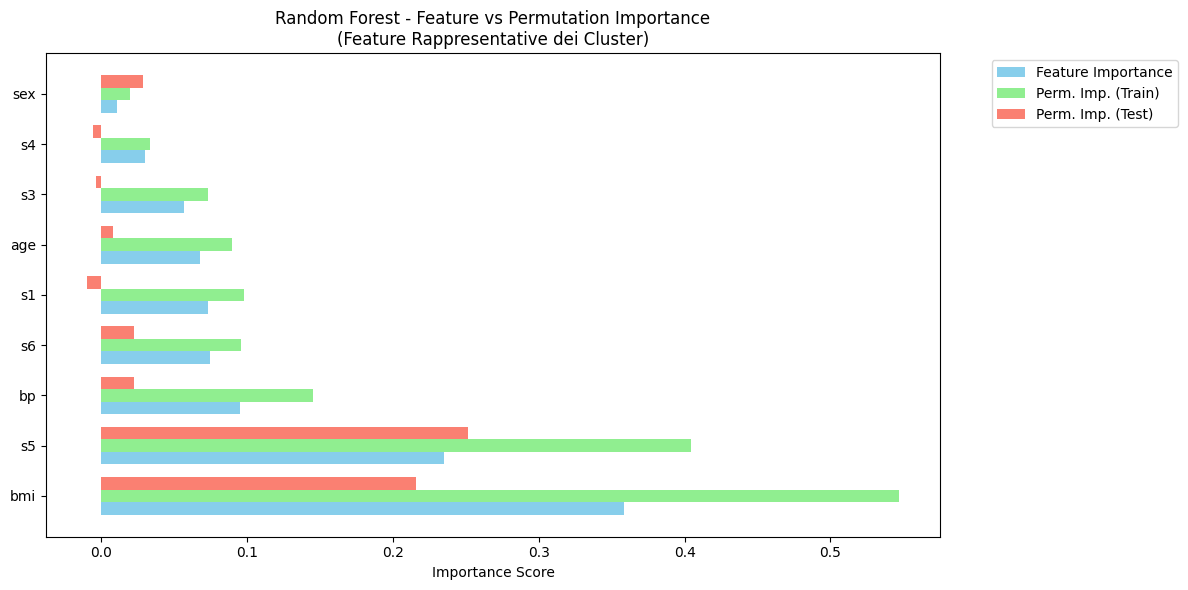

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.stats import spearmanr

# Carica dati
diabetes = load_diabetes()
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = diabetes.target

# Clustering gerarchico
corr = np.abs(spearmanr(X)[0])
dist = 1 - corr
linkage_matrix = linkage(dist, method='complete')
threshold = 0.5
clusters = fcluster(linkage_matrix, threshold, criterion='distance')

# Visualizza dendrogramma
plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix, labels=diabetes.feature_names, color_threshold=threshold)
plt.title('Dendrogramma delle Feature con Soglia di Clustering')
plt.axhline(y=threshold, color='r', linestyle='--', label=f'Soglia = {threshold}')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Analizza e mostra i cluster
cluster_members = {}
cluster_representatives = {}
for cluster_id in np.unique(clusters):
    # Trova membri del cluster
    cluster_features = np.where(clusters == cluster_id)[0]
    cluster_members[cluster_id] = [diabetes.feature_names[i] for i in cluster_features]

    # Scegli rappresentante
    if len(cluster_features) > 1:
        mean_corr = np.mean(corr[cluster_features][:, cluster_features], axis=1)
        representative_idx = cluster_features[np.argmax(mean_corr)]
    else:
        representative_idx = cluster_features[0]
    cluster_representatives[cluster_id] = diabetes.feature_names[representative_idx]

# Mostra composizione cluster
print("\nComposizione dei cluster:")
for cluster_id in cluster_members:
    print(f"\nCluster {cluster_id}:")
    print(f"  Rappresentante: {cluster_representatives[cluster_id]}")
    print(f"  Membri: {', '.join(cluster_members[cluster_id])}")

# Crea dataset ridotto
selected_features = [list(diabetes.feature_names).index(rep) for rep in cluster_representatives.values()]
X_reduced = X.iloc[:, selected_features]

# Split e training
X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, test_size=0.2, random_state=42)
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

# Calcola importance
result_train = permutation_importance(rf, X_train, y_train, n_repeats=10, random_state=42)
result_test = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=42)

# Plot importance
plt.figure(figsize=(12, 6))
feature_names = X_reduced.columns
y_pos = np.arange(len(feature_names))
width = 0.25

# Ordina per importanza
importance_order = np.argsort(rf.feature_importances_)[::-1]  # Ordine decrescente
feature_names = np.array(feature_names)[importance_order]
feat_imp = rf.feature_importances_[importance_order]
perm_imp_train = result_train.importances_mean[importance_order]
perm_imp_test = result_test.importances_mean[importance_order]

plt.barh(y_pos - width, feat_imp, width, label='Feature Importance', color='skyblue')
plt.barh(y_pos, perm_imp_train, width, label='Perm. Imp. (Train)', color='lightgreen')
plt.barh(y_pos + width, perm_imp_test, width, label='Perm. Imp. (Test)', color='salmon')

plt.yticks(y_pos, feature_names)
plt.xlabel('Importance Score')
plt.title('Random Forest - Feature vs Permutation Importance\n(Feature Rappresentative dei Cluster)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()